# Gene Expression Classification: Sparse Logistic Regression
Predicting cancer subtype (ALL vs AML) using L1-regularized logistic regression for minimal feature selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings

warnings.filterwarnings('ignore')

## Data Loading and Preprocessing

In [2]:
# Read the data
actual = pd.read_csv('../data/raw/actual.csv')
test_df = pd.read_csv('../data/raw/data_set_ALL_AML_independent.csv')
train_df = pd.read_csv('../data/raw/data_set_ALL_AML_train.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Actual labels shape: {actual.shape}")

Train shape: (7129, 78)
Test shape: (7129, 70)
Actual labels shape: (72, 2)


In [3]:
# Preprocessing: Remove 'call' columns and restructure
df1 = [col for col in train_df.columns if "call" not in col]
train_df = train_df[df1]
print(f"After removing 'call' columns: {train_df.shape}")

# Transpose and clean
train_df = train_df.T
train_df2 = train_df.drop(['Gene Description', 'Gene Accession Number'], axis=0)
train_df2.index = pd.to_numeric(train_df2.index)
train_df2.sort_index(inplace=True)

print(f"Preprocessed train data shape: {train_df2.shape}")
train_df2.head()

After removing 'call' columns: (7129, 40)
Preprocessed train data shape: (38, 7129)


,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25


In [6]:
# Add cancer type labels (ALL=0, AML=1)
cancer_labels = pd.read_csv('../data/raw/actual.csv')[:38]['cancer'].values
dic = {'ALL': 0, 'AML': 1}
train_df2['cancer_type'] = cancer_labels
train_df2['cancer_type'] = train_df2['cancer_type'].map(dic)

print(f"Class distribution:")
print(train_df2['cancer_type'].value_counts())
print(f"\nClass proportions:")
print(train_df2['cancer_type'].value_counts(normalize=True))

Class distribution:
cancer_type
0    27
1    11
Name: count, dtype: int64

Class proportions:
cancer_type
0    0.710526
1    0.289474
Name: proportion, dtype: float64


## Data Preparation for Classification

In [7]:
X = train_df2.drop('cancer_type', axis=1).values.astype(float)
y = train_df2['cancer_type'].values.astype(int)  # ← Ensures y is integers

In [11]:
# Standardize the features
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print(f"Standardized feature matrix shape: {X_std.shape}")

Standardized feature matrix shape: (38, 7129)


## Sparse Logistic Regression with L1 Penalty

In [12]:
# Train sparse logistic regression model

logreg = LogisticRegression(
    penalty='l1',           # L1 regularization for sparsity
    solver='saga',          # solver that supports L1
    C=0.08,                 # regularization strength
    max_iter=10000,
    tol=1e-4,
    random_state=0,
    class_weight='balanced'
)

logreg.fit(X_std, y)

print(f"\nModel Convergence:")
print(f"Number of iterations: {logreg.n_iter_[0]}")
print(f"Max iterations allowed: 10000")
if logreg.n_iter_[0] < 10000:
    print("Model converged successfully")
else:
    print("Model did not converge - increase max_iter")


Model Convergence:
Number of iterations: 2409
Max iterations allowed: 10000
Model converged successfully


In [13]:
# Extract and analyze selected features
coef = logreg.coef_.ravel()
nonzero_idx = np.where(coef != 0)[0]
nonzero_coef = coef[nonzero_idx]

print("Feature Selection Results")
print(f"Total features: {len(coef)}")
print(f"Non-zero coefficients: {len(nonzero_idx)}")
print(f"Sparsity: {(1 - len(nonzero_idx)/len(coef))*100:.2f}%")
print("Selected Genes (Gene IDs with non-zero coefficients):")

for idx, gene_id in enumerate(nonzero_idx):
    print(f"Gene {gene_id+1:4d}: coefficient = {nonzero_coef[idx]:10.6f}")

print("\nNote: Gene IDs correspond to column indices in the original feature matrix")

Feature Selection Results
Total features: 7129
Non-zero coefficients: 4
Sparsity: 99.94%
Selected Genes (Gene IDs with non-zero coefficients):
Gene 2020: coefficient =   0.142328
Gene 3320: coefficient =   0.163627
Gene 4847: coefficient =   0.109525
Gene 5039: coefficient =   0.083995

Note: Gene IDs correspond to column indices in the original feature matrix


In [15]:
# Training set performance
y_pred_train = logreg.predict(X_std)
train_score = logreg.score(X_std, y)
y_proba_train = logreg.predict_proba(X_std)[:, 1]
train_auc = roc_auc_score(y, y_proba_train)

print("Training Set Performance (on all 38 samples)")
print(f"Accuracy: {train_score:.4f}")
print(f"ROC-AUC: {train_auc:.4f}")

Training Set Performance (on all 38 samples)
Accuracy: 0.9737
ROC-AUC: 1.0000


In [16]:
# Classification report on training set
print("\nClassification Report (Training Set):")
print(classification_report(y, y_pred_train, target_names=['ALL', 'AML']))

# Confusion matrix
cm = confusion_matrix(y, y_pred_train)
print("Confusion Matrix (Training Set):")
print(cm)
print(f"\nTrue Negatives (ALL correctly identified): {cm[0,0]}")
print(f"False Positives (AML misidentified as ALL): {cm[0,1]}")
print(f"False Negatives (ALL misidentified as AML): {cm[1,0]}")
print(f"True Positives (AML correctly identified): {cm[1,1]}")


Classification Report (Training Set):
              precision    recall  f1-score   support

         ALL       1.00      0.96      0.98        27
         AML       0.92      1.00      0.96        11

    accuracy                           0.97        38
   macro avg       0.96      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

Confusion Matrix (Training Set):
[[26  1]
 [ 0 11]]

True Negatives (ALL correctly identified): 26
False Positives (AML misidentified as ALL): 1
False Negatives (ALL misidentified as AML): 0
True Positives (AML correctly identified): 11


## Cross-Validation


In [18]:
# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Create a new model for CV
logreg_cv = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.08,
    max_iter=10000,
    tol=1e-4,
    random_state=0,
    class_weight='balanced'
)

# Cross-validation scores
cv_scores = cross_val_score(logreg_cv, X_std, y, cv=cv, scoring='accuracy')
cv_auc_scores = cross_val_score(logreg_cv, X_std, y, cv=cv, scoring='roc_auc')

print("5-FOLD CROSS-VALIDATION RESULTS")
print(f"\nAccuracy scores per fold: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\nROC-AUC scores per fold: {cv_auc_scores}")
print(f"Mean CV ROC-AUC: {cv_auc_scores.mean():.4f} (+/- {cv_auc_scores.std():.4f})")

5-FOLD CROSS-VALIDATION RESULTS

Accuracy scores per fold: [1.         1.         0.875      0.85714286 0.71428571]
Mean CV Accuracy: 0.8893 (+/- 0.1062)

ROC-AUC scores per fold: [1. 1. 1. 1. 1.]
Mean CV ROC-AUC: 1.0000 (+/- 0.0000)


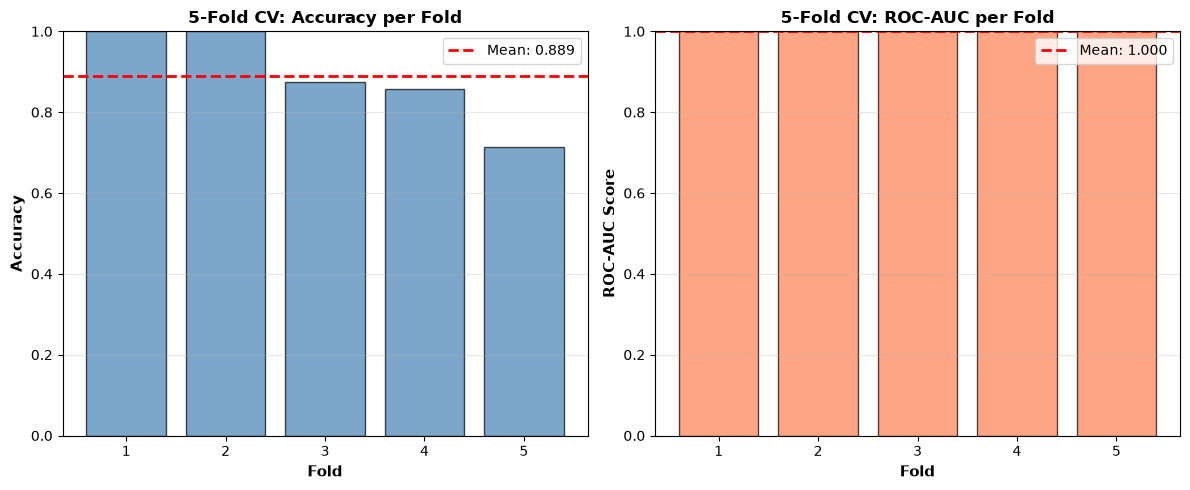

In [19]:
# Visualization of cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
folds = np.arange(1, 6)
axes[0].bar(folds, cv_scores, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axhline(y=cv_scores.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.3f}')
axes[0].set_xlabel('Fold', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('5-Fold CV: Accuracy per Fold', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].legend()
axes[0].set_xticks(folds)

# ROC-AUC
axes[1].bar(folds, cv_auc_scores, color='coral', alpha=0.7, edgecolor='black')
axes[1].axhline(y=cv_auc_scores.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {cv_auc_scores.mean():.3f}')
axes[1].set_xlabel('Fold', fontsize=11, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
axes[1].set_title('5-Fold CV: ROC-AUC per Fold', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()
axes[1].set_xticks(folds)

plt.tight_layout()
plt.show()

## ROC Curve Analysis

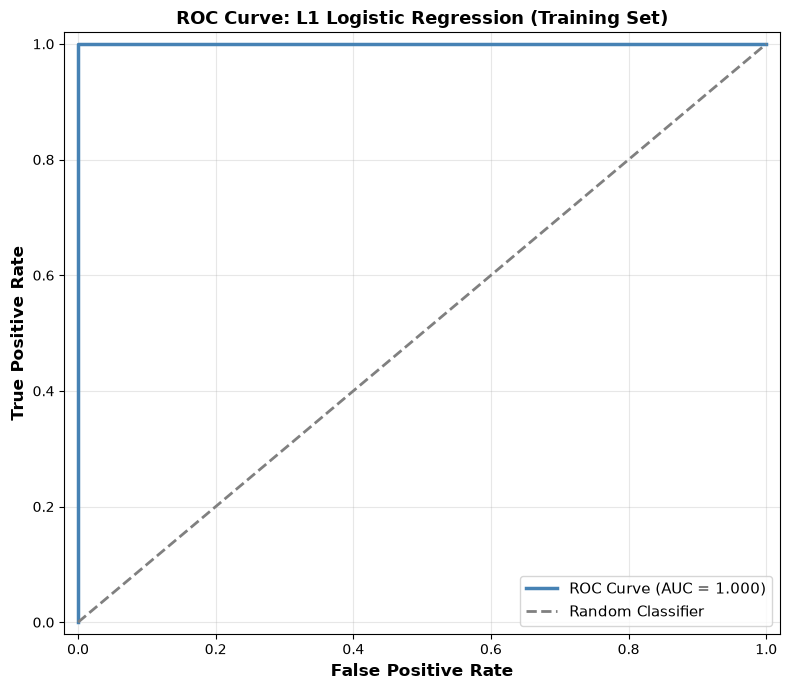

In [20]:
# ROC Curve on training set (for visualization only)
fpr, tpr, thresholds = roc_curve(y, y_proba_train)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color='steelblue', lw=2.5, label=f'ROC Curve (AUC = {train_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve: L1 Logistic Regression (Training Set)', fontsize=13, fontweight='bold')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Comparison

In [23]:
# Performance summary
print("SUMMARY: SPARSE LOGISTIC REGRESSION FOR GENE EXPRESSION CLASSIFICATION")

summary = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Sample Size'],
    'Training Set': [
        f"{train_score:.4f}",
        f"{train_auc:.4f}",
        "38 (all samples)"
    ],
    '5-Fold CV (mean±std)': [
        f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
        f"{cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}",
        "~30 train  ~8 test per fold"
    ]
})

print(summary.to_string(index=False))


SUMMARY: SPARSE LOGISTIC REGRESSION FOR GENE EXPRESSION CLASSIFICATION
     Metric     Training Set        5-Fold CV (mean±std)
   Accuracy           0.9737             0.8893 ± 0.1062
    ROC-AUC           1.0000             1.0000 ± 0.0000
Sample Size 38 (all samples) ~30 train  ~8 test per fold


## Coefficient Visualization

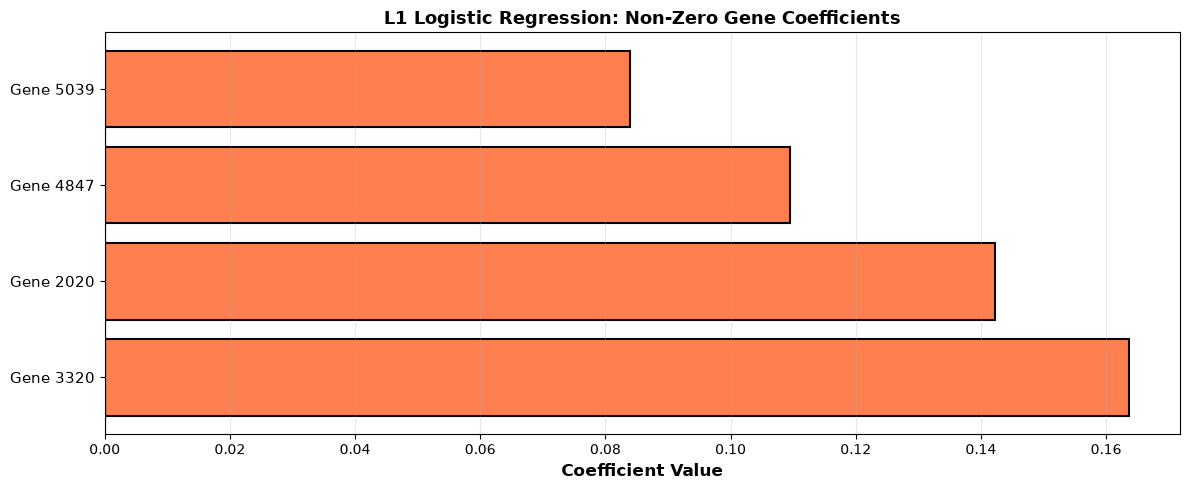


Selected genes ranked by coefficient magnitude:
1. Gene 3320: 0.163627
2. Gene 2020: 0.142328
3. Gene 4847: 0.109525
4. Gene 5039: 0.083995


In [24]:
# Plot coefficients
fig, ax = plt.subplots(figsize=(12, 5))

# Create sorted coefficient plot (only non-zero)
sorted_indices = np.argsort(np.abs(nonzero_coef))[::-1]
sorted_genes = nonzero_idx[sorted_indices]
sorted_coefs = nonzero_coef[sorted_indices]

colors = ['steelblue' if c < 0 else 'coral' for c in sorted_coefs]
ax.barh(range(len(sorted_coefs)), sorted_coefs, color=colors, edgecolor='black', linewidth=1.5)

ax.set_yticks(range(len(sorted_coefs)))
ax.set_yticklabels([f'Gene {g+1}' for g in sorted_genes], fontsize=11)
ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('L1 Logistic Regression: Non-Zero Gene Coefficients', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nSelected genes ranked by coefficient magnitude:")
for i, (gene_id, coef_val) in enumerate(zip(sorted_genes, sorted_coefs), 1):
    print(f"{i}. Gene {gene_id+1}: {coef_val:.6f}")